In [73]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import pickle
import matplotlib.pyplot as plt
import seaborn as sns


In [84]:
with open('sequences.txt', 'r') as f:
    sequences = f.readlines()
sequences = [seq.strip() for seq in sequences if seq.strip()]


with open('labels.txt', 'r') as f:
    labels = f.readlines()
labels = [int(label.strip()) for label in labels if label.strip()]


print(f"Number of sequences: {len(sequences)}")
print(f"Number of labels: {len(labels)}")

print(f"First 15 sequences: {sequences[:15]}")
print(f"First 15 labels: {labels[:15]}")

Number of sequences: 2000
Number of labels: 2000
First 15 sequences: ['CCGAGGGCTATGGTTTGGAAGTTAGAACCCTGGGGCTTCTCGCGGACACC', 'GAGTTTATATGGCGCGAGCCTAGTGGTTTTTGTACTTGTTTGTCGCGTCG', 'GATCAGTAGGGAAACAAACAGAGGGCCCAGCCACATCTAGCAGGTAGCCT', 'GTCCACGACCGAACTCCCACCTTGACCGCAGAGGTACCACCAGAGCCCTG', 'GGCGACCGAACTCCAACTAGAACCTGCATAACTGGCCTGGGAGATATGGT', 'AGACATTGTCAGAACTTAGTGTGCGCCGCACTGAGCGACCGAACTCCGAC', 'CCCGGCGAAGGCTGACGAATCCTCGACCGAACTCCAGTGAAGCCAACCGG', 'AGGCAGGTGGTCGTACAATGTTTTCGAAGAGATAGGGGGCCAGAGGCCTC', 'TACTGCCTATAGCGAAGAGCGCGAGAGGTATATCGAAGAATACCGAGCAA', 'CGTATCTTCGTGTGCTCTCCTTTAGAACTGCATCTCTAGAGTCAGAGAGG', 'CCCGTTGCCTCATCTATTTTAGTTCTCGACGACCGAACTCCGTCCCGGGA', 'GCCGTCTATATCCAGAATTACTGTTGAGAAAGACGCATACCGTGCATAAT', 'TTTGAGGTTGACGATTACTTTAGTGCTTCTGACGACCGAACTCCGCGGGT', 'CCAGCAAGTCGAAGCTTACTCCATGATTTTTCACCGACCGAACTCCAGTA', 'GGTACGGCTGAGACACACATAATGGATACCAGGAACGACGTCGGCTCGAA']
First 15 labels: [0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0]


In [74]:


# encode sequences 

def mapping_seq(seq):
    mapping = {'A':[1, 0, 0, 0],
               'C':[0, 1, 0, 0],
               'G':[0, 0, 1, 0],
               'T':[0, 0, 0, 1]}
    return [mapping[base] for base in seq]

def encode_sequences(sequences):
    encoded = [mapping_seq(seq) for seq in sequences]
    return np.array(encoded)


sequences_encoded = encode_sequences(sequences)
sequences_encoded = np.transpose(sequences_encoded, (0, 2, 1))  # shape: (num_sequences, 4, seq_length)

labels = np.array(labels).reshape(-1)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [75]:
labels[0].dtype

dtype('int64')

In [76]:
# data  and splitting

def Data(sequences, labels):
    X = np.array(sequences)
    y = np.array(labels)

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)


    X_validation, X_test, y_validation, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=42)
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    X_validation = torch.tensor(X_validation, dtype=torch.float32).to(device)
    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_train = torch.tensor(y_train, dtype=torch.long).to(device)
    y_validation = torch.tensor(y_validation, dtype=torch.long).to(device)
    y_test = torch.tensor(y_test, dtype=torch.long).to(device)
    return X_train, X_validation, X_test, y_train, y_validation, y_test

X_train, X_validation, X_test, y_train, y_validation, y_test = Data(sequences_encoded, labels)

X_train.shape, X_validation.shape, X_test.shape, y_train.shape, y_validation.shape, y_test.shape
   

(torch.Size([1200, 4, 50]),
 torch.Size([400, 4, 50]),
 torch.Size([400, 4, 50]),
 torch.Size([1200]),
 torch.Size([400]),
 torch.Size([400]))

In [77]:
class GenomicCNN(nn.Module):
    def __init__(self, seq_length: int, input_channels: int = 4):
        super(GenomicCNN, self).__init__()
        self.conv1 = nn.Conv1d(input_channels, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)
        self.relu = nn.ReLU()
        # self.dropout = nn.Dropout(0.2)
        
        # Final sequence length after two poolings (each halves the length)
        pooled_seq_len = seq_length // 4 
        
        self.fc = nn.Linear(32 * pooled_seq_len, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.conv1(x)) 
        x = self.pool(x)            
        # x = self.dropout(x)
        
        x = self.relu(self.conv2(x))  
        x = self.pool(x)              
        # x = self.dropout(x)
        
        x = x.view(x.size(0), -1)   
        x = self.fc(x)
        x = self.sigmoid(x)
        return x



def train_model(model, X_train, y_train, X_validation, y_validation, epochs=1000, batch_size=32, learning_rate=0.001, patience=10):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    X_validation = X_validation.to(device)
    y_validation = y_validation.to(device)
    model.train()
    train_losess = []
    val_losess = []

    
    
    best_val_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        permutation = torch.randperm(X_train.size(0))
        
        for i in range(0, X_train.size(0), batch_size):
            indices = permutation[i:i + batch_size]
            batch_x, batch_y = X_train[indices], y_train[indices].float()
            
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs.squeeze(), batch_y)
            
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(X_validation)
            val_loss = criterion(val_outputs.squeeze(), y_validation.float())
        val_losess.append(val_loss.item())
        train_losess.append(loss.item())
        if (epoch + 1) % 10 == 0:
            print(f'Epoch [{epoch + 1}/{epochs}], Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}')
             # plotting the loss
            plt.figure(figsize=(10, 5))
            plt.plot(train_losess, label='Training Loss')
            plt.plot(val_losess, label='Validation Loss')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')
            plt.title(f'Training and Validation Loss for Epoch {epoch + 1}')
            plt.legend()
            plt.savefig(f'loss_epoch_{epoch + 1}.png')
            plt.close()


        # Early stopping

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= patience:
            print("Early stopping triggered")
            break
    print("Training complete")
    # Save the model
    torch.save(model.state_dict(), 'genomic_cnn_model.pth')
    





In [78]:
# Initialize and train the model
seq_length = X_train.shape[2]
model = GenomicCNN(seq_length=seq_length).to(device)
train_model(model, X_train, y_train, X_validation, y_validation, epochs=1000, batch_size=32, learning_rate=0.001, patience=10)



Epoch [10/1000], Loss: 0.1155, Val Loss: 0.1170
Epoch [20/1000], Loss: 0.0131, Val Loss: 0.0469
Epoch [30/1000], Loss: 0.0099, Val Loss: 0.0233
Epoch [40/1000], Loss: 0.0021, Val Loss: 0.0159
Epoch [50/1000], Loss: 0.0011, Val Loss: 0.0119
Epoch [60/1000], Loss: 0.0023, Val Loss: 0.0084
Epoch [70/1000], Loss: 0.0005, Val Loss: 0.0076
Epoch [80/1000], Loss: 0.0002, Val Loss: 0.0063
Epoch [90/1000], Loss: 0.0001, Val Loss: 0.0073
Epoch [100/1000], Loss: 0.0001, Val Loss: 0.0059
Early stopping triggered
Training complete


              precision    recall  f1-score   support

           0       1.00      0.99      0.99       205
           1       0.98      1.00      0.99       195

    accuracy                           0.99       400
   macro avg       0.99      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



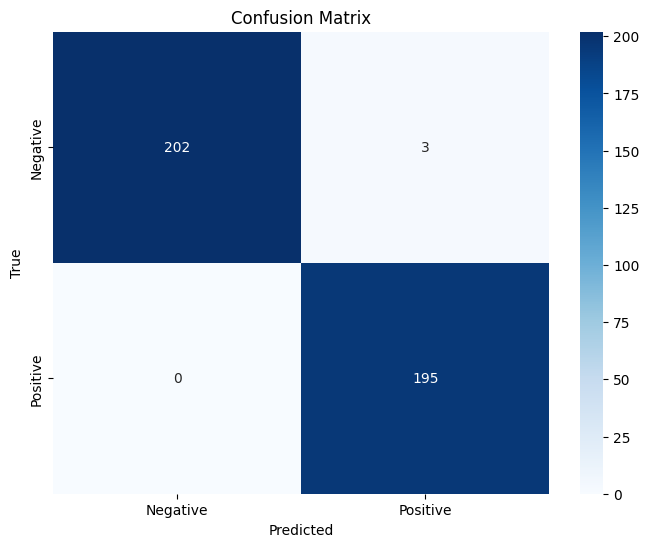

Test Accuracy: 0.9925


In [81]:
model.eval()
def evaluate_model(model, X_test, y_test):
    model.to(device)
    X_test = X_test.to(device)
    y_test = y_test.to(device)
    
    with torch.no_grad():
        outputs = model(X_test)
        predictions = (outputs.squeeze() > 0.5).long()
        accuracy = (predictions == y_test).float().mean().item()
    # Print classification report
    print(classification_report(y_test.cpu(), predictions.cpu()))
    # Print confusion matrix
    cm = confusion_matrix(y_test.cpu(), predictions.cpu())
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.savefig('confusion_matrix.png')
    plt.show()
    plt.close()
        
    print(f'Test Accuracy: {accuracy:.4f}')
    return accuracy
accuracy = evaluate_model(model, X_test, y_test)
